# Classification of Astronomical Events using CNNs (II)
```Authors: Paul Alvarez updated: 20260730```

This study implements and evaluates various computer vision models to classify astronomical events from the Zwicky Transient Facility (ZTF) survey. The main objective is to perform real-bogus classification using 63×63 pixel triplet images (science, reference, and difference) and analyze its performance in a reduced sample size. Additionally, it extends to multiclass classification (transient, periodic, stochastic) and includes transfer learning experiments using MobileNetV2 and Braai.


This second notebook covers the construction of the convolutional neural network baseline model. It also evaluates model enhancements through techniques such as data augmentation and transfer learning, while addressing the selection of an optimal decision threshold to control false positive and false negative rates in the real/bogus classification.

## Table of contents:
* [Required libraries](#Required-libraries)
* [Baseline model](#Baseline-model)
* [Optimization](#optimization)
* [Transfer learning](#transfer-learning)
* [Threshold](#threshold)
* [References](#References)

## Required libraries

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
# visualizations and data analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model performance metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE

# Tensor (CNN's)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


# Helper functions
from functions import evaluate_cnn_model, plot_training_history, comp_thresh
from utils_braai import load_model_helper, plot_error_comp

In [3]:
# Read the data of the previous notebook and split to train models
X = np.load('../data/processed/X_data.npy')
y = np.load('../data/processed/y_labels.npy')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Baseline model

Baseline model is defined: a 5-layer Convolutional Neural Network (3 convolutional layers and 2 dense/fully-connected layers) with a final sigmoid activation function for binary real/bogus classification

In [4]:
# CNN baseline (based on TensorFlow documentation)
def baseline_cnn(input_shape=(63, 63, 3)):
    model = models.Sequential()

    # Convolutional layers
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))

    # Fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid')) # Output layer 

    # Compile
    model.compile(
        optimizer='adam',
        loss= 'binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [31]:
# Model training (only 8 epochs to prevent overfitting due to small dataset)
base_model = baseline_cnn(input_shape=(63,63,3))

history_base = base_model.fit(
    X_train, y_train,
    epochs=8,
    validation_data=(X_test, y_test)
)

Epoch 1/8
123/123 [==============================] - 8s 57ms/step - loss: 0.5537 - accuracy: 0.6988 - val_loss: 0.5499 - val_accuracy: 0.7782
Epoch 2/8
123/123 [==============================] - 6s 50ms/step - loss: 0.3886 - accuracy: 0.8411 - val_loss: 0.4077 - val_accuracy: 0.8383
Epoch 3/8
123/123 [==============================] - 7s 53ms/step - loss: 0.3197 - accuracy: 0.8704 - val_loss: 0.3978 - val_accuracy: 0.8464
Epoch 4/8
123/123 [==============================] - 6s 48ms/step - loss: 0.2657 - accuracy: 0.8923 - val_loss: 0.3787 - val_accuracy: 0.8596
Epoch 5/8
123/123 [==============================] - 7s 59ms/step - loss: 0.2454 - accuracy: 0.9040 - val_loss: 0.3714 - val_accuracy: 0.8657
Epoch 6/8
123/123 [==============================] - 6s 48ms/step - loss: 0.2203 - accuracy: 0.9147 - val_loss: 0.3353 - val_accuracy: 0.8769
Epoch 7/8
123/123 [==============================] - 6s 50ms/step - loss: 0.1905 - accuracy: 0.9252 - val_loss: 0.4682 - val_accuracy: 0.8484
Epoch 

In [6]:
# Observe the architecture (this need discussion)
base_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 61, 61, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 30, 30, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 64)        36928     
                                                                 
 flatten (Flatten)           (None, 9216)              0

31/31 [==============================] - 1s 15ms/step - loss: 0.3502 - accuracy: 0.8830
Accuracy: 0.8830111622810364
31/31 [==============================] - 1s 18ms/step


<Figure size 800x600 with 0 Axes>

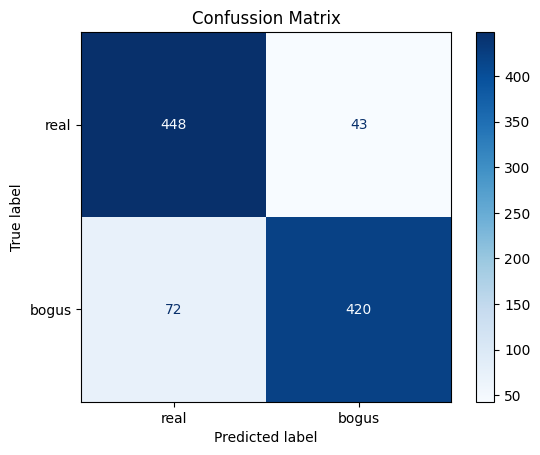


               ===== Classification report =====
              precision    recall  f1-score   support

        real       0.86      0.91      0.89       491
       bogus       0.91      0.85      0.88       492

    accuracy                           0.88       983
   macro avg       0.88      0.88      0.88       983
weighted avg       0.88      0.88      0.88       983



In [7]:
# Display the model performance metrics
loss_base, acc_base = base_model.evaluate(X_test, y_test)
print("Accuracy:", acc_base)
metrics_base = evaluate_cnn_model(base_model, X_test, y_test)

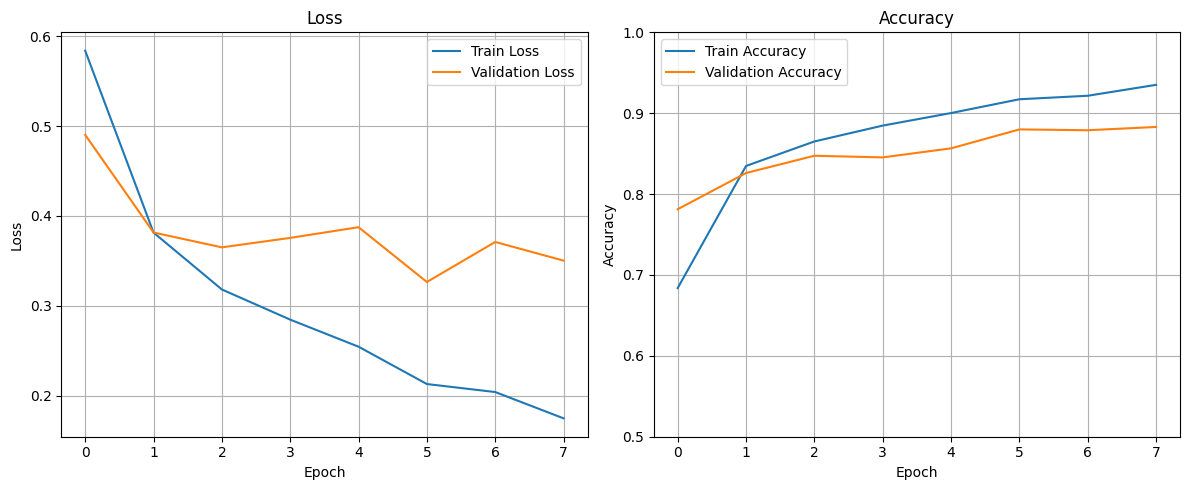

In [8]:
# Plot loss and accuracy visualization
plot_training_history(history_base)

The model achieves an overall accuracy of approximately 90%, demonstrating strong predictive capability well above random guessing. It exhibits high effectiveness to identify correct astronomical objects is high, as is its ability to identify both real and bogus objects. In the astronomy field, maximing the Recalll (or F1-score as well) for the real class is critical, as missinng true discoveries (false negatives such as ignoring a supernova explotion) carries a high science lost. In fact, the baseline model concentrating more false negative errors than false positives, therefore, this is a clear area for improvement.

Regarding the visualizations, the training loss decreases steadily throughout the epochs. However, the validation loss curve begins to diverge from epoch 2 onward, reaching its maximum gap at the final epoch, which provides clear evidence of overfitting. While the training and validation accuracy curves reamin close, a slight divergence emerges near the end, reinforcing the overfitting and epoch limit discussion.


Overall, we achieved competitive results for a lightweight baseline model on a limited dataset. Moving forward, Our goal going forward, beyond further improving predictive performance, our primary goal is to ensure consistencia across evaluation metrics which involvess enhancing model generaization, mitigating overfitting, and narrowing the gap between training and validation loss curves.

  


## Optimization

### Data Augmentation and Dropout

With the baseline model established, we now evaluate the impact of techniques such as data augmentation (artificially expanding  the dataset through flips, crops, and rotation of the images) and dropout (randomly deactivating neurons during training to prevent overfitting  and prioritize general feature representation) on stabilizing and improving our model:

In [9]:
# Baseline plus data augmentation and dropout
def baseline_cnn_plus(input_shape=(63, 63, 3), num_classes=10):
    model = models.Sequential()

    data_augmentation = tf.keras.Sequential([ #aug
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.1, 0.1),
    ])


    # Convolutional layers
    model.add(data_augmentation) # plus data via augmentation

    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    #model.add(layers.BatchNormalization())  
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25)) # dropout

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    #model.add(layers.BatchNormalization())  
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25)) # dropout

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    #model.add(layers.BatchNormalization())  

    # Dense layers
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    

    # This block is used for the multiclass extension in notebook III
    if num_classes <= 2:
        # Binary (Real vs Bogus) SIGMOIDE activation (used in this notebook)
        n_cat = 1
        activation = 'sigmoid'
        loss = 'binary_crossentropy'

    else:
        # Multiclass (3+) SOFTMAX activation
        n_cat = num_classes
        activation = 'softmax'
        loss = 'sparse_categorical_crossentropy' # simple label 0,1,2

    # Its depends on multiclass o binary classification
    model.add(layers.Dense(n_cat, activation=activation))

    model.compile(
        optimizer='adam',
        loss=loss,
        metrics=['accuracy']
    )
    return model

Since regularization techniques such as data augmentation and dropout mitigate the risk of overfitting, the numbers of training epochs is setted higher to allow the network more time to achieve convergence and improve accuracy. Additionally, we implemented early stopping with a patience of 5 epochs to automatically halt training once the validation loss stabilizes, preventing extra computation. 

In [10]:
# training model
model_plus = baseline_cnn_plus(input_shape=(63,63,3), num_classes=2)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_plus = model_plus.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32, # small dataset
    callbacks=[early_stop]
)

# architecture
model_plus.summary()

Epoch 1/50
99/99 [==============================] - 9s 60ms/step - loss: 0.5484 - accuracy: 0.7145 - val_loss: 0.5524 - val_accuracy: 0.6921
Epoch 2/50
99/99 [==============================] - 6s 58ms/step - loss: 0.4641 - accuracy: 0.7944 - val_loss: 0.4431 - val_accuracy: 0.8104
Epoch 3/50
99/99 [==============================] - 6s 60ms/step - loss: 0.4036 - accuracy: 0.8285 - val_loss: 0.3919 - val_accuracy: 0.8346
Epoch 4/50
99/99 [==============================] - 6s 61ms/step - loss: 0.3734 - accuracy: 0.8456 - val_loss: 0.3515 - val_accuracy: 0.8575
Epoch 5/50
99/99 [==============================] - 6s 60ms/step - loss: 0.3514 - accuracy: 0.8488 - val_loss: 0.3902 - val_accuracy: 0.8155
Epoch 6/50
99/99 [==============================] - 7s 69ms/step - loss: 0.3381 - accuracy: 0.8520 - val_loss: 0.3471 - val_accuracy: 0.8537
Epoch 7/50
99/99 [==============================] - 6s 64ms/step - loss: 0.3211 - accuracy: 0.8721 - val_loss: 0.3001 - val_accuracy: 0.8804
Epoch 8/50
99

31/31 [==============================] - 1s 30ms/step - loss: 0.2083 - accuracy: 0.9196
Accuracy: 0.9196337461471558
31/31 [==============================] - 2s 22ms/step


<Figure size 800x600 with 0 Axes>

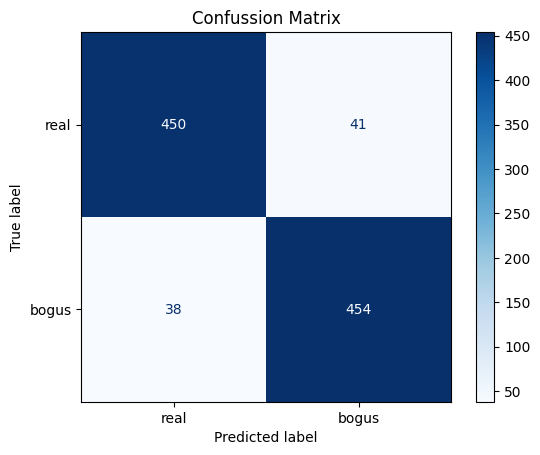


               ===== Classification report =====
              precision    recall  f1-score   support

        real       0.92      0.92      0.92       491
       bogus       0.92      0.92      0.92       492

    accuracy                           0.92       983
   macro avg       0.92      0.92      0.92       983
weighted avg       0.92      0.92      0.92       983



In [11]:
# Display the model performance metrics
loss_plus, acc_plus = model_plus.evaluate(X_test, y_test)
print("Accuracy:", acc_plus)
metrics_plus = evaluate_cnn_model(model_plus, X_test, y_test)

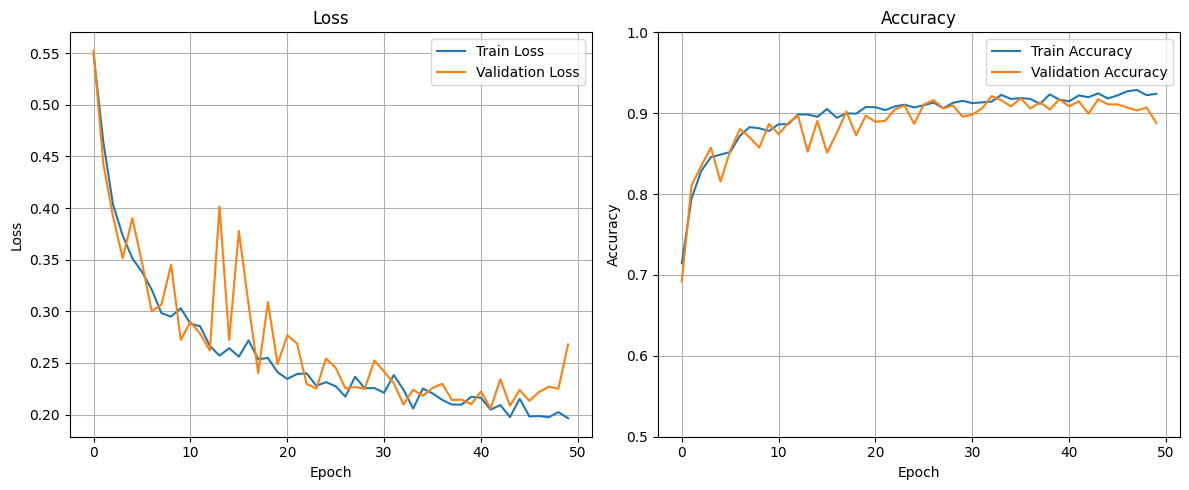

In [12]:
# Visualizations of the Loss and Accuracy
plot_training_history(history_plus)

The model shows a clerly improvement in accuracy, reaching approximately 92%. Classification performance is high across both classes, with precision and recall stabilizing in contrast to baseline model (with a gap of 20% in recall performance). Furthermore, we observe a better balance between false positive (FP) and false negative (FN) errors, with a reduction in the number of FN errors, the most scientifically error type in the study.

The visualizations also show clear improvement. The loss curves are much better stabilized and show no significant divergence, indicating that overfitting has been effectively mitigated. We attribute this stability directly to data augmentation, which expand our effective training set to up 100,000 synthetic samples, reducing the constraints of a small dataset. Addiotionally, dropout randomly deactivates neurons during training, preventing overfitting and forcing the network to learn more generalized features (this yield better performance on the unseen test set, $X_{test}$).


## Transfer Learning



We investigate the feasibility of transfer learning for astronomical real/bogus classification by applying weights previously trained on millions of data points applied to our baseline model. We will analyze the domain effectiveness of transfer learning by comparing two approaches: on the one hand, using MobileNetV2 weights as an external domain (learned from ImageNet), and on the other hand, using weights from the Braai architecture, a Real/Bogus classifier trained on millions of ZFT stamps (just like the baseline CNN) as an identical specific domain.

### MobileNetV2

We loaded a pre-trained MobileNetV2 architecture, removing its final 1000-class classification layer and freezing the pre-trained weights. Then, we appended a binary classification top layer to adapt the architecture to our real/bogus task. Consequently, MobileNetV2 only serves as a feature extractor (the ability to detect low-level edges, shapes, and complex patterns, without performing the final decision)

In [32]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False, # The last layer is used for +1000 class
    input_shape=(63, 63, 3)
)

# Freeze all baseline layers (no modify the weights loaded)
base_model.trainable = False

In [14]:
# Add layers for baseline data
inputs = layers.Input(shape=(63, 63, 3))
x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)
net_model = models.Model(inputs, outputs)

net_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Architecture
net_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 63, 63, 3)]       0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 2, 2, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense_4 (Dense)             (None, 128)               163968    
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 1)                 129   

In [15]:
# Model training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_net = net_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
99/99 [==============================] - 15s 104ms/step - loss: 0.5725 - accuracy: 0.7212 - val_loss: 0.4872 - val_accuracy: 0.7697
Epoch 2/50
99/99 [==============================] - 7s 69ms/step - loss: 0.4699 - accuracy: 0.7778 - val_loss: 0.4755 - val_accuracy: 0.7710
Epoch 3/50
99/99 [==============================] - 7s 66ms/step - loss: 0.4502 - accuracy: 0.7845 - val_loss: 0.4836 - val_accuracy: 0.7621
Epoch 4/50
99/99 [==============================] - 6s 61ms/step - loss: 0.4499 - accuracy: 0.7893 - val_loss: 0.4361 - val_accuracy: 0.8028
Epoch 5/50
99/99 [==============================] - 6s 60ms/step - loss: 0.4400 - accuracy: 0.7928 - val_loss: 0.4441 - val_accuracy: 0.8092
Epoch 6/50
99/99 [==============================] - 6s 63ms/step - loss: 0.4354 - accuracy: 0.8001 - val_loss: 0.4533 - val_accuracy: 0.8028
Epoch 7/50
99/99 [==============================] - 6s 59ms/step - loss: 0.4314 - accuracy: 0.7989 - val_loss: 0.4877 - val_accuracy: 0.7659
Epoch 8/50


31/31 [==============================] - 1s 44ms/step - loss: 0.4009 - accuracy: 0.8138
Accuracy: 0.8138352036476135
31/31 [==============================] - 2s 43ms/step


<Figure size 800x600 with 0 Axes>

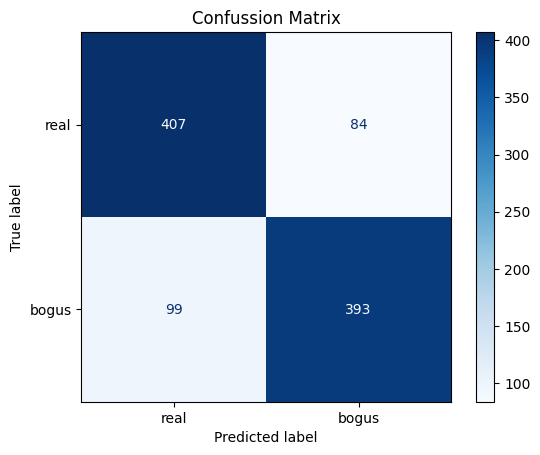


               ===== Classification report =====
              precision    recall  f1-score   support

        real       0.80      0.83      0.82       491
       bogus       0.82      0.80      0.81       492

    accuracy                           0.81       983
   macro avg       0.81      0.81      0.81       983
weighted avg       0.81      0.81      0.81       983



In [16]:
# Display some metrics
loss_net, acc_net = net_model.evaluate(X_test, y_test)
print("Accuracy:", acc_net)
metrics_net = evaluate_cnn_model(net_model, X_test, y_test)


The transfer learning model achieved decent overall performance, particularly given that only the classification head was trained to adapt to our dataset. ImageNet features transferred reasonably well despite being a totally different domain (between natural images and astronomical stamps). However, the false negative (FN) rate remains critically high compared to prior architectures trained.

## Braai

braai is a convolutional-neural-network, deep-learning real/bogus classifier designed to separate genuine astrophysical events and objects from false positive, or bogus, detections in the data of the Zwicky Transient Facilty (ZTF).

Initially, we establish a base performance by evaluating the original Braai model on our dataset. Building upon this, we investigate both partial and full fine-tuning (warm start) approaches by analyzing evidence of a possible domain shift and determining an appropriate learning rate.

In [17]:
# Load Braai model and weights 
model_braai_base = load_model_helper(path='../models', model_base_name='d6_m7')  
model_braai_base.compile(
    optimizer= 'adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

loss_braai_base, acc_braai_base = model_braai_base.evaluate(X_test, y_test)
print(f"Original braai accuracy: {acc_braai_base:.4f}")

31/31 [==============================] - 1s 10ms/step - loss: 1.3388 - accuracy: 0.4476
Original braai accuracy: 0.4476


Using the pre-trained Braai model on our dataset exhibits poor performance, with an accuracy of approximately 44.76%. This drop in accuract suggest that the original convolutional filters do not generalize well to our stamps and a possible domain shift arising from differences in image processing, despite  both the Braai model and our current networks being trained on ZFT data.

To mitigate this issue, we analyze different transfer learning strategies:

- Feature extraction: Freezing all convolutional layers of Braai to use as feature extraction.

- Partial fine-tuning: Unfreezing only the final convolutional block (conv4) and applying a reduced learning rate.

- Warm start (Full fine-tuning): Retraining the entire network using the original Braai weights as initialization.

In [18]:
# Baseline plus with Braai as feature extractor
def baseline_tl(model_fe, input_shape=(63, 63, 3), num_classes=10, optimizer='adam'):

    """
    Helper function which contains the braai architecture
    and freeze the top layer to use the model only as feature
    extractor
    """
    model = models.Sequential()

    # Instead our layers we use Braai
    model.add(model_fe) # Braai model as features
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))

    # This block is used for the multiclass extension in notebook III
    if num_classes <= 2:
        # Binary (Real vs Bogus) SIGMOIDE activation (used in this notebook)
        n_cat = 1
        activation = 'sigmoid'
        loss = 'binary_crossentropy'

    else:
        # Multiclass (3+) SOFTMAX activation
        n_cat = num_classes
        activation = 'softmax'
        loss = 'sparse_categorical_crossentropy' # simple label 0,1,2

    # Its depends on multiclass o binary classification
    model.add(layers.Dense(n_cat, activation=activation))

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    return model

In [19]:
# Use the model only for feature extractor (freeze all original layers, no update the learned weights)
model_fe = tf.keras.Model(inputs=model_braai_base.inputs, outputs=model_braai_base.layers[-2].output)
for layer in model_fe.layers:
    layer.trainable = False

model_tl_v0 = baseline_tl(model_fe=model_fe, num_classes=2)
model_tl_v0.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model_1 (Functional)        (None, 256)               311824    
                                                                 
 dense_6 (Dense)             (None, 64)                16448     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 1)                 65        
                                                                 
Total params: 328337 (1.25 MB)
Trainable params: 16513 (64.50 KB)
Non-trainable params: 311824 (1.19 MB)
_________________________________________________________________


In [20]:
# Model training
history_tl_v0 = model_tl_v0.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32, # small dataset
    callbacks=[early_stop]
)

loss_tl_v0, acc_tl_v0 = model_tl_v0.evaluate(X_test, y_test)
print("Accuracy:", acc_tl_v0)

Epoch 1/50
99/99 [==============================] - 2s 17ms/step - loss: 0.6978 - accuracy: 0.5532 - val_loss: 0.6740 - val_accuracy: 0.5954
Epoch 2/50
99/99 [==============================] - 2s 15ms/step - loss: 0.6776 - accuracy: 0.5754 - val_loss: 0.6635 - val_accuracy: 0.6081
Epoch 3/50
99/99 [==============================] - 2s 16ms/step - loss: 0.6678 - accuracy: 0.5837 - val_loss: 0.6543 - val_accuracy: 0.6094
Epoch 4/50
99/99 [==============================] - 2s 15ms/step - loss: 0.6614 - accuracy: 0.5961 - val_loss: 0.6504 - val_accuracy: 0.6056
Epoch 5/50
99/99 [==============================] - 2s 16ms/step - loss: 0.6566 - accuracy: 0.5939 - val_loss: 0.6459 - val_accuracy: 0.6310
Epoch 6/50
99/99 [==============================] - 2s 15ms/step - loss: 0.6596 - accuracy: 0.6022 - val_loss: 0.6455 - val_accuracy: 0.6361
Epoch 7/50
99/99 [==============================] - 2s 18ms/step - loss: 0.6547 - accuracy: 0.6047 - val_loss: 0.6452 - val_accuracy: 0.6158
Epoch 8/50
99

In [21]:
# Fine tunning
for layer in model_fe.layers:
    if layer.name == 'conv4':
        layer.trainable = True
    else:
        layer.trainable = False

optimizer = Adam(learning_rate=1e-4)
model_tl_v1 = baseline_tl(model_fe=model_fe, num_classes=2, optimizer=optimizer)
model_tl_v1.summary()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model_1 (Functional)        (None, 256)               311824    
                                                                 
 dense_8 (Dense)             (None, 64)                16448     
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_9 (Dense)             (None, 1)                 65        
                                                                 
Total params: 328337 (1.25 MB)
Trainable params: 25761 (100.63 KB)
Non-trainable params: 302576 (1.15 MB)
_________________________________________________________________


In [22]:
# Model training
history_tl_v1 = model_tl_v1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

loss_tl_v1, acc_tl_v1 = model_tl_v1.evaluate(X_test, y_test)
print("Accuracy:", acc_tl_v1)

Epoch 1/50
99/99 [==============================] - 3s 21ms/step - loss: 0.7304 - accuracy: 0.5048 - val_loss: 0.6956 - val_accuracy: 0.4542
Epoch 2/50
99/99 [==============================] - 2s 21ms/step - loss: 0.7064 - accuracy: 0.4984 - val_loss: 0.6926 - val_accuracy: 0.4885
Epoch 3/50
99/99 [==============================] - 2s 21ms/step - loss: 0.6946 - accuracy: 0.5121 - val_loss: 0.6900 - val_accuracy: 0.5204
Epoch 4/50
99/99 [==============================] - 2s 21ms/step - loss: 0.6927 - accuracy: 0.5369 - val_loss: 0.6869 - val_accuracy: 0.5369
Epoch 5/50
99/99 [==============================] - 2s 19ms/step - loss: 0.6876 - accuracy: 0.5353 - val_loss: 0.6830 - val_accuracy: 0.5687
Epoch 6/50
99/99 [==============================] - 2s 21ms/step - loss: 0.6839 - accuracy: 0.5757 - val_loss: 0.6778 - val_accuracy: 0.5954
Epoch 7/50
99/99 [==============================] - 2s 21ms/step - loss: 0.6816 - accuracy: 0.5687 - val_loss: 0.6736 - val_accuracy: 0.6196
Epoch 8/50
99

In [24]:
# See the base base model performance (via warm start)
model_braai_base = load_model_helper(path='../models', model_base_name='d6_m7')  

model_braai_base.compile(
    optimizer= 'adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_tl = model_braai_base.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

loss_braai_base, acc_braai_base = model_braai_base.evaluate(X_test, y_test)
print(f"Original braai Accuracy (trained): {acc_braai_base:.4f}")


Epoch 1/50
99/99 [==============================] - 9s 66ms/step - loss: 0.6415 - accuracy: 0.6426 - val_loss: 0.6345 - val_accuracy: 0.7099
Epoch 2/50
99/99 [==============================] - 6s 61ms/step - loss: 0.4883 - accuracy: 0.7839 - val_loss: 0.4386 - val_accuracy: 0.8232
Epoch 3/50
99/99 [==============================] - 6s 56ms/step - loss: 0.4191 - accuracy: 0.8310 - val_loss: 0.4002 - val_accuracy: 0.8397
Epoch 4/50
99/99 [==============================] - 9s 91ms/step - loss: 0.3920 - accuracy: 0.8450 - val_loss: 0.3667 - val_accuracy: 0.8435
Epoch 5/50
99/99 [==============================] - 7s 73ms/step - loss: 0.3422 - accuracy: 0.8689 - val_loss: 0.3365 - val_accuracy: 0.8639
Epoch 6/50
99/99 [==============================] - 7s 66ms/step - loss: 0.3522 - accuracy: 0.8651 - val_loss: 0.3447 - val_accuracy: 0.8779
Epoch 7/50
99/99 [==============================] - 7s 74ms/step - loss: 0.3081 - accuracy: 0.8854 - val_loss: 0.3180 - val_accuracy: 0.8804
Epoch 8/50
99

31/31 [==============================] - 1s 16ms/step


<Figure size 800x600 with 0 Axes>

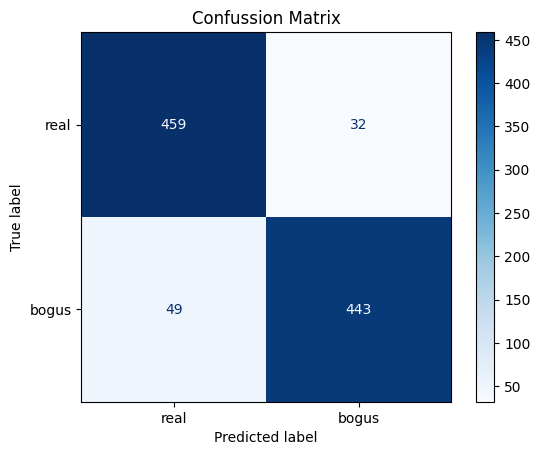


               ===== Classification report =====
              precision    recall  f1-score   support

        real       0.90      0.93      0.92       491
       bogus       0.93      0.90      0.92       492

    accuracy                           0.92       983
   macro avg       0.92      0.92      0.92       983
weighted avg       0.92      0.92      0.92       983



In [25]:
# Display model metrics
metrics_braai = evaluate_cnn_model(model_braai_base, X_test, y_test)

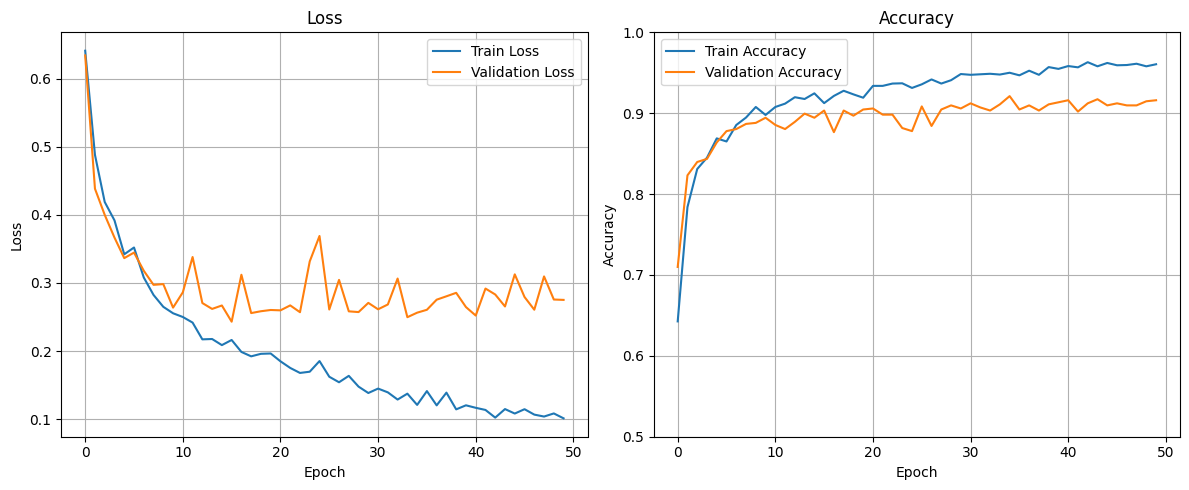

In [26]:
# Visualizations of the Loss and Accuracy
plot_training_history(history_tl)

Based on the observed results, we conclude that transfer learning is effective; however, the feature extraction method (freezing layers) is insufficient when there is evidence of a domain shift. Full fine-tuning was required to obtain optimal results. Furthermore, the Braai model exhibits overfitting. This can be explained by its highly parameterized architecture and the absence of regularization techniques, such as data augmentation, which makes it prone to overfitting on our smaller dataset. Nevertheless, although the primary metruca to maximize was accuracy, transfer learning techniques demonstrably lead to faster convergence (reaching nearly 90% accuracy in just 5 epochs) and reduced computation time.

## Threshold value

Having established a reliable model with good predictive performance, we now explores strategies to reduce false negatives, which represent the most critical errors in our context. Specifically, we investigate the impact of the decision threshold (the probability used to classify a detection as real or bogus, set 0.5 defaulta) on the distribution of false negatives and false positives.

31/31 [==============================] - 0s 13ms/step
Th: 0.5, FNR: 7.7236%, FPR: 8.3503%


c:\Users\Paul\Documents\Github\ztf-real-bogus-cnn\notebooks\utils_braai.py:160: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.1%}'.format(x) if x < 0.01 else '{:,.0%}'.format(x) for x in vals])


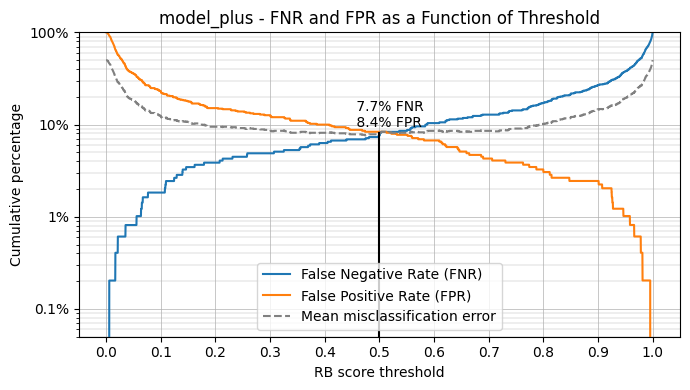

In [27]:
# Display FN and FP distribution 
y_prob = model_plus.predict(X_test)
plot_error_comp("model_plus", y_test, y_prob, thresholds=[0.5])

The figure above the model's performance as a function of the decision threshold value used (the default sigmoid value used of 0.5 is marked in black). Primarily, we can observe that as the threshold increases, the false negative rate (FN) increases, while the false positive rate (FP) decreases.

Within the visualization, we can distinguish two optimal threshold: a theorical optimun based purely on metric geometry, and a domain specific one based on the astronomical phenomenon. The theorical optimum refers to the point where the curves intersect, resulting in an equal error rate. In the confusion matrix, this would translate to a balanced number of FNs and FPs. In our case, this value is approximately 0. The scientific optimum reflecs our scenario, where the goal is to decrease the false negative rate. Therefore, the ideal threshold value would be lower. However, we can not simply set the threshold down to 0, as the model's effectiveness would be compromised by the noise of excessive false positive predictions. Now, to balance this, we establish a criterion based on the mean misclassification error (MME), selecting the point just before the overall error starts to increase, which gives us an approximate threshold of 0.2

Finally, we evaluate the effect of these calibrated threshold on the model's overall accuracy, quantifying the trade-off of reducing the false negativas by increasing the false positive rate and, possibly, reducing accuracy.

In [30]:
# Compare the choosen optimal thresholds
y_probs = model_plus.predict(X_test)

thresh_theo = 0.5
thresh_sci = 0.2
comp_thresh(y_probs, y_test, thresh_theo, thresh_sci)

31/31 [==============================] - 1s 22ms/step
Optimal Threshold 0.5 (math) ===
Accuracy: 0.9196337741607324
[[450  41]
 [ 38 454]]

Optimal Threshold 0.2 (science) ===
Accuracy: 0.9053916581892166
[[417  74]
 [ 19 473]]


The implemented demonstrates us the cost of reducing the number of false negatives (FNs) using the domain specific and theorical optimum. We conclude that adjusting the decision threshold is a highly viable strategy: overall accuracy only decreases by only $\approx 1\%$, leaving us with just 19 critical errors (FPs), 1.9% of the total validation data. On the other hand, increasing the false positive (FP) rate merely translates to time wasted analyzing bogus phenomena.  but scientific progress will not be lost because the priority is to capture the maximum number of true alerts. Most importantly, no underlying scientific discoveries are disregard.

## References

- Duev, D. A., Mahabal, A., Masci, F. J., Graham, M. J., Rusholme, B., Walters, R., Karmarkar, I., Frederick, S., Kasliwal, M. M., & Rebbapragada, U. (2019). *Real-bogus classification for the Zwicky Transient Facility using deep learning (braai)*. *Monthly Notices of the Royal Astronomical Society, 489*(3), 3582–3590. https://doi.org/10.1093/mnras/stz2357
- Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L.-C. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)*, 4510–4520. https://doi.org/10.1109/CVPR.2018.00474
- Abadi, M., et al. (2016). *TensorFlow: A System for Large-Scale Machine Learning*. *Proceedings of the 12th USENIX Symposium on Operating Systems Design and Implementation (OSDI)*, 265–283.